# Tutorial: Snapshot-based Real/Bogus Classification

This tutorial shows how to load a pre-trained CNN model and run Real/Bogus inference  
on **25×25 pixel FITS snapshots** from 7DT difference images.

| Label | Meaning |
|-------|---------|
| **Real (1)** | Genuine astrophysical transient |
| **Bogus (0)** | Subtraction artifact, cosmic ray, etc. |

> **Kernel**: activate the `rbc` conda environment before running  
> (`conda activate rbc`, then open Jupyter)

---
## 0. Setup

In [19]:
import os, sys, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath('..')   # run from notebook/
sys.path.insert(0, PROJECT_ROOT)

import torch
from astropy.io import fits
from src.model import RBClassificationModule

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


In [20]:
# ── Choose model version ──────────────────────────────────────────────────────
MODEL_VERSION  = 'v3_resnet34'   # see performance table below

CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, 'output', 'snapshot', 'checkpoints')
SNAPSHOT_DIR   = os.path.join(PROJECT_ROOT, 'data', 'norm_snapshot')
SUMMARY_CSV    = os.path.join(PROJECT_ROOT, 'output', 'summary', 'compare_results.csv')

ckpt_files = glob.glob(os.path.join(CHECKPOINT_DIR, MODEL_VERSION, '*.ckpt'))
if not ckpt_files:
    raise FileNotFoundError(f'No checkpoint found: {CHECKPOINT_DIR}/{MODEL_VERSION}/')
CHECKPOINT_PATH = sorted(ckpt_files)[-1]
print(f'Checkpoint : {os.path.basename(CHECKPOINT_PATH)}')

Checkpoint : rb-classifier-epoch=01-val_loss=0.05.ckpt


---
## 1. Pre-computed Performance

All models were trained and evaluated on 7DT difference-image snapshots (tile-based split).  
The numbers below are stored results — **no recomputation needed**.

In [21]:
summary = pd.read_csv(SUMMARY_CSV)
snap_cols = ['version', 'model_type', 'auroc', 'f1_macro', 'accuracy']
snap = (
    summary[summary['pipeline'] == 'snapshot'][snap_cols]
    .dropna(subset=['auroc'])
    .sort_values('auroc', ascending=False)
    .reset_index(drop=True)
)
snap.columns = ['Version', 'Architecture', 'AUROC', 'F1-macro', 'Accuracy']
snap

,Version,Architecture,AUROC,F1-macro,Accuracy
0,NaN,simplecnn,0.997911,0.992579,0.998354
1,NaN,mobilenet_,0.997840,0.989421,0.997640
2,NaN,resnet34,0.997660,0.994405,0.998768
3,NaN,efficientnet_b1,0.997658,0.991859,0.998195
4,NaN,resnet18,0.997650,0.990573,0.997903
5,NaN,resnet,0.997618,0.998903,0.997936
6,NaN,resnet50,0.997441,0.991130,0.998030
7,NaN,convnext_tiny,0.997375,0.962591,0.991227
8,NaN,shufflenet_v2,0.997311,0.993815,0.998635
9,NaN,otrain,0.997292,0.991344,0.998078


---
## 2. Load Pre-trained Model

In [22]:
model = RBClassificationModule.load_from_checkpoint(
    CHECKPOINT_PATH, map_location=device
)
model.eval().to(device)

print(f'Architecture : {model.hparams.model_name}')
print(f'Device       : {device}')

Architecture : resnet34
Device       : cuda


---
## 3. Inference Demo

### Input
A **25×25 FITS cutout** from a difference image, normalized with MAD + arcsinh.

### Output
`rb_score` ∈ [0, 1] — probability of being **Real**.  
Apply a threshold (default 0.5) to get a binary label.

```
FITS file  →  normalize  →  CNN  →  sigmoid  →  rb_score  →  label
```

In [23]:
def normalize_mad_asinh(img, k=2.0, post_clip=3, eps=1e-8):
    """MAD-based robust normalization + arcsinh compression (same as training)."""
    x = img.astype(np.float32, copy=False)
    m = np.isfinite(x)
    if not np.any(m):
        return np.zeros_like(x, dtype=np.float32)
    med   = np.median(x[m])
    sigma = 1.4826 * np.median(np.abs(x[m] - med))
    if sigma < eps:
        return np.zeros_like(x, dtype=np.float32)
    x = np.arcsinh((x / sigma) / k)
    x = np.clip(x, -post_clip, post_clip)
    x[~m] = 0.0
    return x


def predict(model, fits_paths, device='cpu', normalize=True):
    """
    Parameters
    ----------
    fits_paths : list of str   — paths to .fits snapshot files
    normalize  : bool          — True for raw cutouts, False for pre-normalized files

    Returns
    -------
    rb_scores : numpy array (N,)  — Real probability for each file
    """
    model = model.to(device).eval()
    images = []
    for p in fits_paths:
        try:
            img = fits.getdata(p).astype(np.float32)
        except Exception:
            img = np.zeros((25, 25), dtype=np.float32)
        if normalize:
            img = normalize_mad_asinh(img)
        images.append(img[np.newaxis] if img.ndim == 2 else img)  # (1, H, W)

    x = torch.from_numpy(np.stack(images)).to(device)
    with torch.no_grad():
        rb_scores = torch.sigmoid(model(x).squeeze(1)).cpu().numpy()
    return rb_scores

In [24]:
# Pick 5 Real (sci) and 5 Bogus (sub) examples from the test tile
test_tile   = sorted(glob.glob(os.path.join(SNAPSHOT_DIR, 'T*')))[-1]
real_files  = sorted(glob.glob(os.path.join(test_tile, 'sci', '*.fits')))[:5]
bogus_files = sorted(glob.glob(os.path.join(test_tile, 'sub', '*.fits')))[:5]

# data/norm_snapshot is already normalized → normalize=False
real_scores  = predict(model, real_files,  device=device, normalize=False)
bogus_scores = predict(model, bogus_files, device=device, normalize=False)

print(f'Test tile : {os.path.basename(test_tile)}')
print(f'Real  rb_scores : {np.round(real_scores, 3)}')
print(f'Bogus rb_scores : {np.round(bogus_scores, 3)}')

Test tile : T00216
Real  rb_scores : [0.997 0.989 0.997 0.998 0.996]
Bogus rb_scores : [0. 0. 0. 0. 0.]


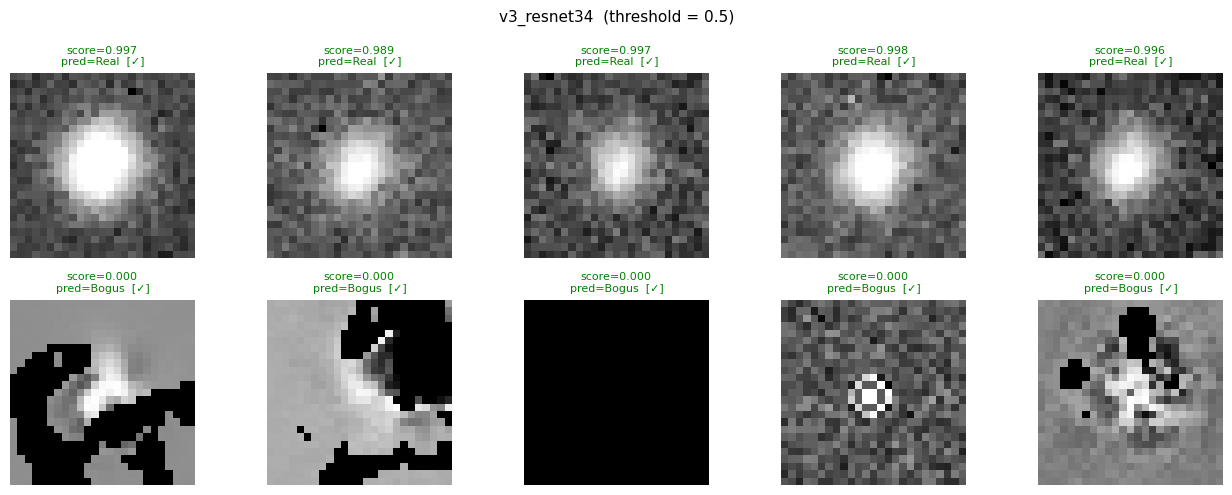

In [25]:
# Visualize: images side-by-side with predicted score
THRESHOLD = 0.5

all_files  = real_files + bogus_files
all_scores = np.concatenate([real_scores, bogus_scores])
all_labels = ['Real'] * 5 + ['Bogus'] * 5

fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for ax, path, score, true_label in zip(axes.flat, all_files, all_scores, all_labels):
    img  = fits.getdata(path).astype(np.float32)
    pred = 'Real' if score >= THRESHOLD else 'Bogus'
    ok   = (pred == true_label)
    ax.imshow(img, cmap='gray', origin='lower')
    ax.set_title(
        f'score={score:.3f}\npred={pred}  [{"✓" if ok else "✗"}]',
        fontsize=8,
        color='green' if ok else 'red'
    )
    ax.axis('off')

axes[0][0].set_ylabel('True: Real',  fontsize=9)
axes[1][0].set_ylabel('True: Bogus', fontsize=9)
fig.suptitle(f'{MODEL_VERSION}  (threshold = {THRESHOLD})', fontsize=11)
plt.tight_layout()
plt.show()

---
## 4. Applying to Your Own Data

Provide a list of FITS file paths — no labels needed.

```python
# Raw cutouts (not yet normalized) → normalize=True
my_files  = ['obs1/snap_001.fits', 'obs1/snap_002.fits', ...]
rb_scores = predict(model, my_files, device=device, normalize=True)

# Apply threshold
labels = ['Real' if s >= 0.5 else 'Bogus' for s in rb_scores]
```

### Expected input format
- FITS file containing a **25×25 pixel** background-subtracted difference-image cutout  
- Pixel values in ADU (normalization is applied inside `predict()` when `normalize=True`)

### Pre-trained model options

| `MODEL_VERSION` | Architecture | AUROC |
|-----------------|-------------|-------|
| `v3_resnet34` | ResNet-34 | 0.9977 |
| `v3_efficientnet_b1` | EfficientNet-B1 | 0.9977 |
| `v3_simplecnn` | Simple CNN | 0.9979 |
| `v3_resnet18` | ResNet-18 | 0.9977 |